In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df=pd.read_csv('/Users/aditi/Downloads/Customer Churn (1).csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.columns = df.columns.str.strip()



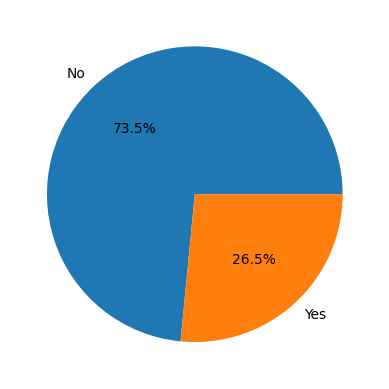

In [12]:
gb = df['Churn'].value_counts()

plt.pie(gb, labels=gb.index, autopct='%1.1f%%')
plt.show()

# it explains that 26.5% of the customers are churned out 
# now we will analyse the reason why this has happened

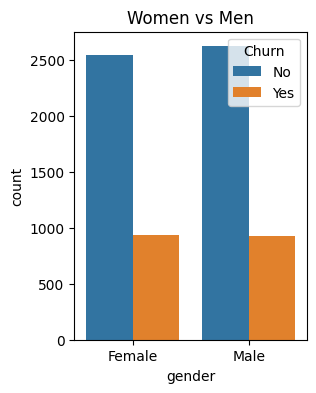

In [22]:
plt.figure(figsize=(3,4))
sns.countplot(x="gender", data=df, hue="Churn")
plt.title("Women vs Men")
plt.show()

In [11]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.isnull().sum()
df.describe()



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [ ]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df("seniorcitizen")=df("seniorcitizen").apply(conv)

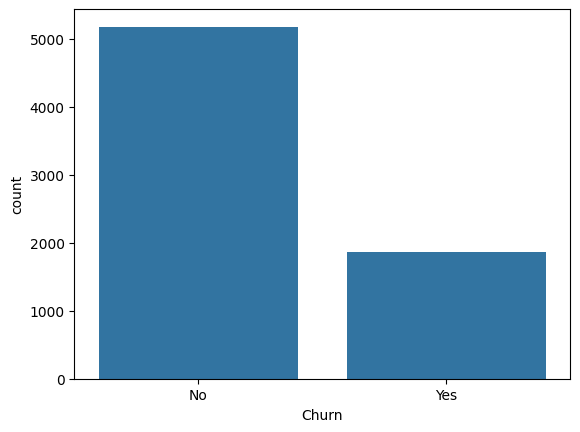

In [18]:
sns.countplot(x='Churn', data=df)
plt.show()

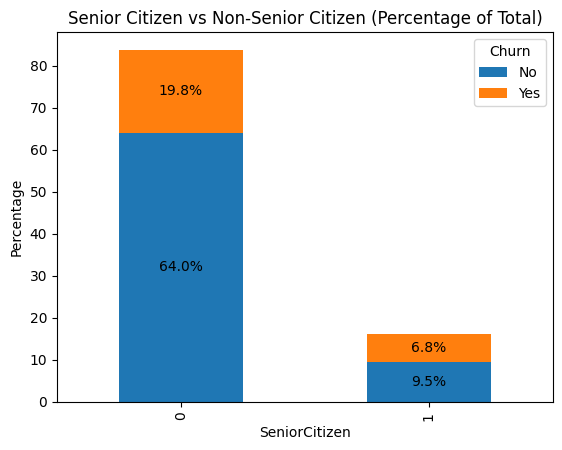

In [24]:
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"])

# convert to percentage of total
ct_per = ct / ct.values.sum() * 100

# plot stacked bar chart
ax = ct_per.plot(kind="bar", stacked=True)

# add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.title("Senior Citizen vs Non-Senior Citizen (Percentage of Total)")
plt.ylabel("Percentage")
plt.xlabel("SeniorCitizen")
plt.show()

Text(0.5, 0, 'Tenure (months)')

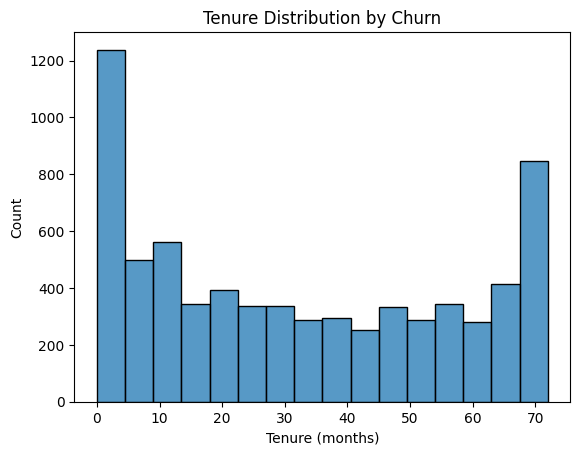

In [26]:
sns.histplot(data=df, x="tenure")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")

In [ ]:
df.columns.values



array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

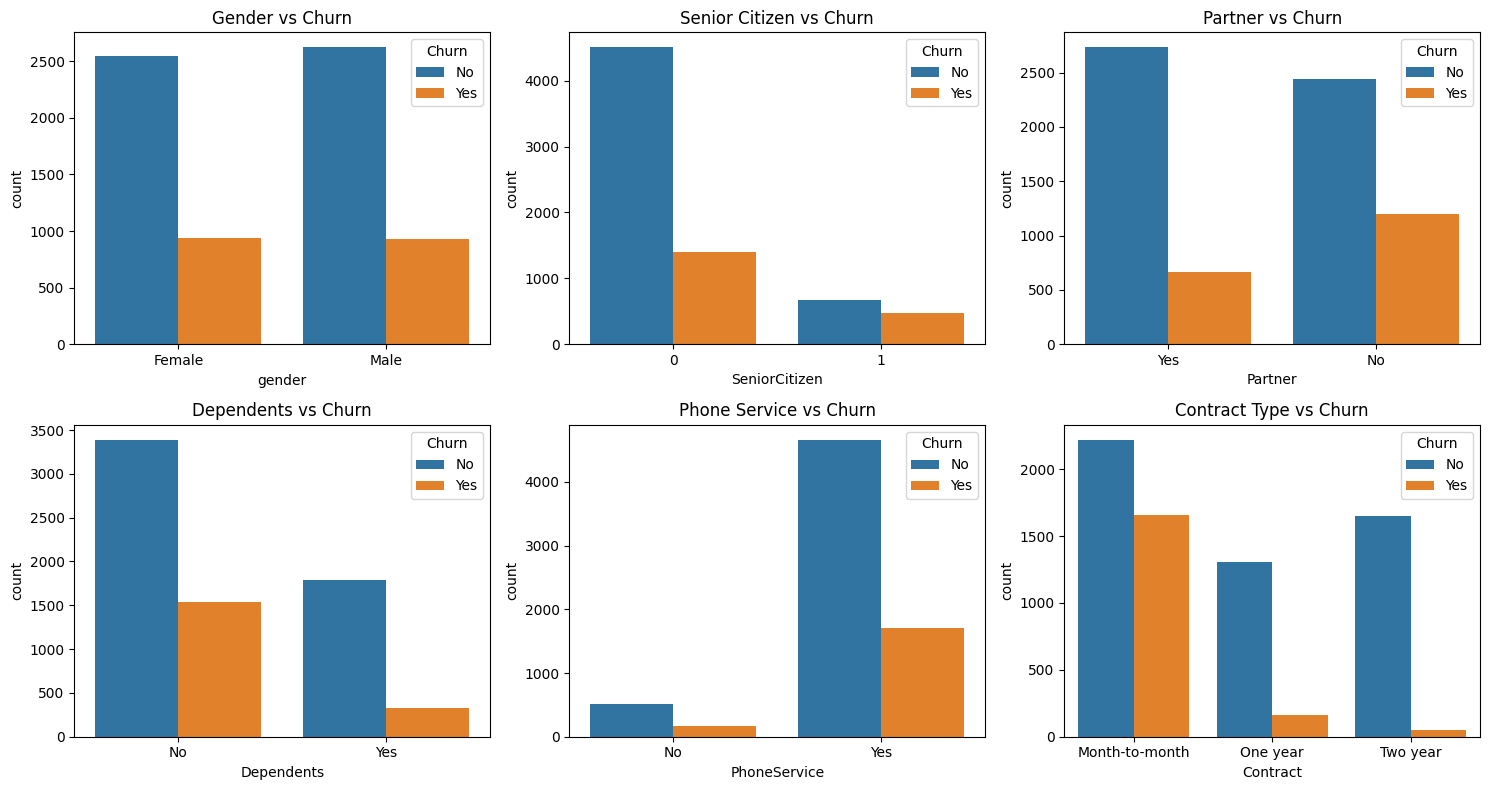

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.countplot(x="gender", data=df, hue="Churn", ax=axes[0,0])
axes[0,0].set_title("Gender vs Churn")

sns.countplot(x="SeniorCitizen", data=df, hue="Churn", ax=axes[0,1])
axes[0,1].set_title("Senior Citizen vs Churn")

sns.countplot(x="Partner", data=df, hue="Churn", ax=axes[0,2])
axes[0,2].set_title("Partner vs Churn")

sns.countplot(x="Dependents", data=df, hue="Churn", ax=axes[1,0])
axes[1,0].set_title("Dependents vs Churn")

sns.countplot(x="PhoneService", data=df, hue="Churn", ax=axes[1,1])
axes[1,1].set_title("Phone Service vs Churn")

sns.countplot(x="Contract", data=df, hue="Churn", ax=axes[1,2])
axes[1,2].set_title("Contract Type vs Churn")

plt.tight_layout()
plt.show()